In [2]:
import scanpy as sc
from scib_metrics.benchmark import Benchmarker 

c:\Users\irc\miniconda3\envs\scib\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load in datasets

In [3]:
adata = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_Samuel_anndataR.h5ad")

In [9]:
adata_anno = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_integrated_anndataR.h5ad")

Because the "celltype_new" column is not in Samuel's object, we add it manually here for the benchmark

In [11]:
adata.obs["celltype_new"] = adata_anno.obs["celltype_new"]

In [12]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'celltype_new'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject_mean', 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratP

In [19]:
adata.obsm["X_umap"] = adata.obsm["RNA_harmony_umap"]

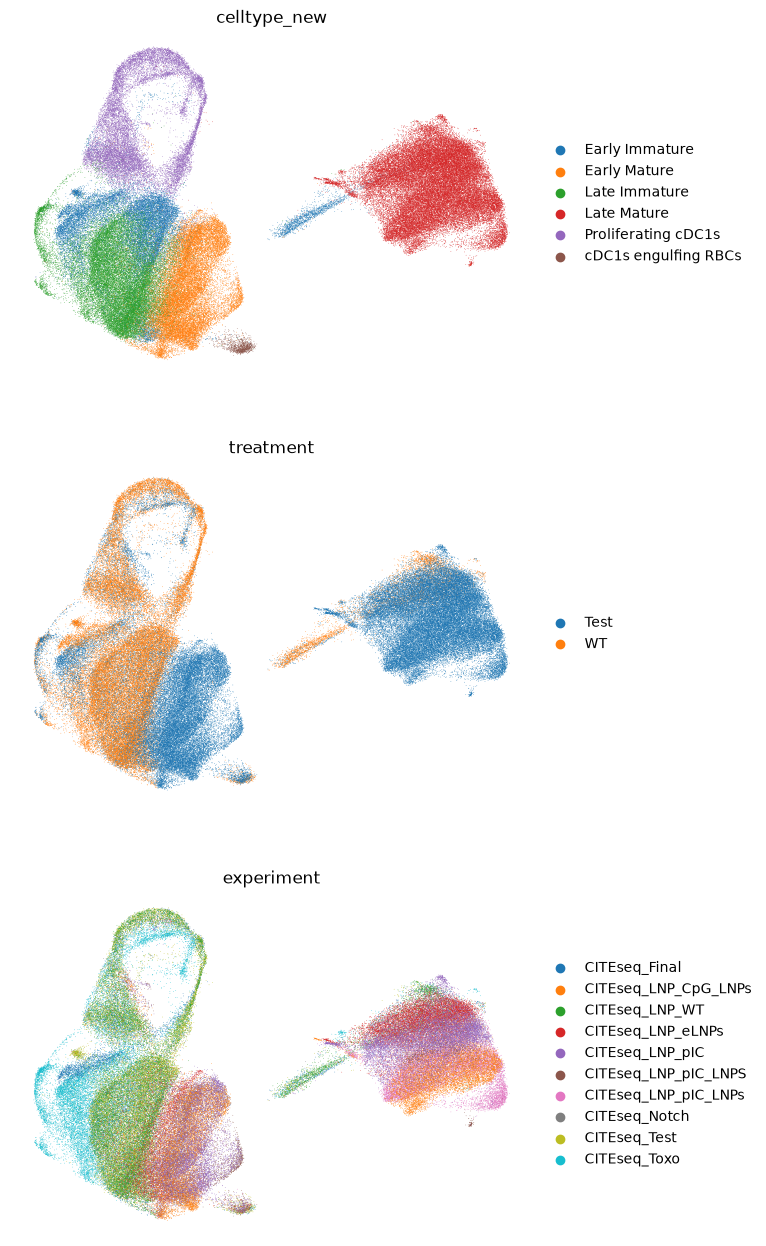

In [25]:
sc.pl.umap(
    adata,
    color = ["celltype_new", "treatment", "experiment"],
    frameon= False,
    ncols=1
)

Run benchmarker

In [ ]:
# Quick benchmark on 10 000 cells to verify output
# adata_sub = sc.pp.subsample(adata, n_obs=10000, copy=True)

Score explanation: 
Bio conservation
- Isolated labels: How effectively rare or dataset-specific cell types (cell types only present in a few batches) are preserved and separated without getting mistakenly mixed into larger populations.
- KMeans NMI: Normalized Mutual Information after running k-means clustering on the integrated space. It measures how much shared information exists between the k-means clusters and the true cell-type labels. 
- KMeans ARI: Adjusted Rand Index after K-means clustering. It measures the proportion of correct cell pair assignments (same cel types in the same cluster), while adjusting for random chance.
- Silhouette label: Cell Type Average Silhouette Width (ASW) measures how well separated cell-type clusters are compared to their neighboring cell types (compactness and separation of cell types).
- cLISI: cell-type local inverse Simpson's index. This evaluates local neighbourhoods around every cell to ensure they contain only a single cell type.

Batch correction:
- BRAS: Batch Removal ASW Score. Measures silhouette score on batch labels inside each cell-type cluster, rescaled so that uniform mixing of batches receives a high score.
- iLISI: integration local inverse Simpson's Index. Measures batch diversoty in the immediate nearest-neighbor neighbborhood of every cell.
- KBET: K-nearest neighbor Batch Effect Test. Tests whether the local batch proportion around each cel matches the global batch distribution of the entire dataset.
- Graph connectivity: Checks whether cells belonging to the same cell type form a single continuous graph component across batches, rather than splitting into disconnected batch islands.
- PCR comparison: Principal component regression, which quantifies how much total expression variance explained by the batch covariate was successfully removed after integration compared to before.


Embeddings: 100%|██████████| 1/1 [29:58<00:00, 1798.61s/it]


              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
RNA_harmony          0.468757          0.537043          0.540085   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
RNA_harmony          0.558791          0.999578           0.94661   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
RNA_harmony          0.121321           0.13704           0.912841   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
RNA_harmony          0.390696  

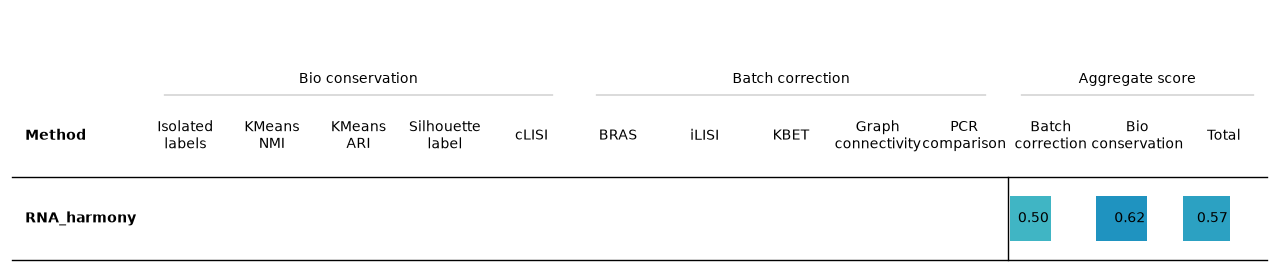

In [ ]:
# 4. Run scib-metrics on the consolidated AnnData object
bm = Benchmarker(
    adata,
    batch_key="experiment",
    label_key="celltype_new",
    embedding_obsm_keys=["RNA_harmony"],
    n_jobs=-1
)

bm.benchmark()
results_df = bm.get_results()
print(results_df)
bm.plot_results_table(min_max_scale=False)

# For each embedding, the same calculation is done 


Embeddings: 100%|██████████| 1/1 [29:24<00:00, 1764.94s/it]


              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
RNA_harmony          0.547917          0.537043          0.540085   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
RNA_harmony          0.558791          0.999578          0.936943   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
RNA_harmony          0.093841           0.16135           0.912841   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
RNA_harmony          0.106308  

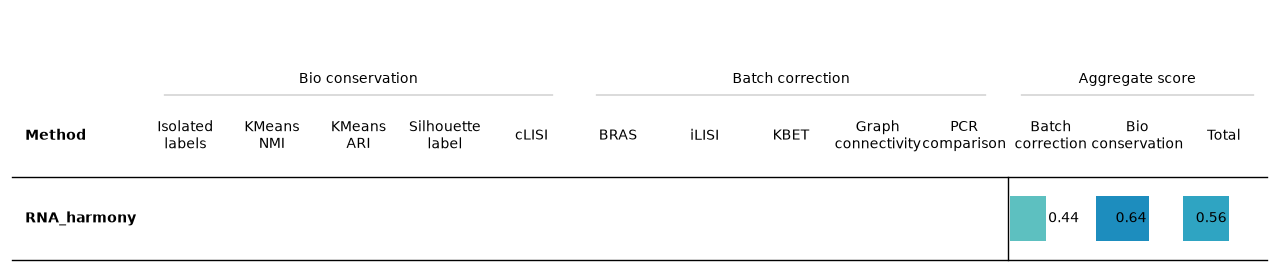

In [31]:
# 4. Run scib-metrics on the consolidated AnnData object
bm = Benchmarker(
    adata,
    batch_key="orig.ident",
    label_key="celltype_new",
    embedding_obsm_keys=["RNA_harmony"],
    n_jobs=-1
)

bm.benchmark()
results_df = bm.get_results()
print(results_df)
bm.plot_results_table(min_max_scale=False)
